<a href="https://colab.research.google.com/github/kartiikb/end-to-end-ML/blob/master/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df=pd.read_csv("household_energy_consumption.csv")

In [30]:
df.sample(10)

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
84864,H12124,2025-04-04,20.0,6,18.9,Yes,9.9
26401,H03772,2025-04-05,6.1,2,16.1,No,2.1
86578,H12369,2025-04-03,17.7,6,21.6,No,6.4
7512,H01074,2025-04-02,11.3,3,16.6,Yes,5.5
43976,H06283,2025-04-03,3.0,1,17.8,Yes,1.4
88657,H12666,2025-04-03,15.6,6,13.5,No,5.7
84789,H12113,2025-04-06,1.3,1,15.1,Yes,0.5
40387,H05770,2025-04-05,20.0,6,17.0,Yes,9.0
62318,H08903,2025-04-05,6.9,2,15.9,Yes,3.4
84587,H12084,2025-04-07,20.0,6,16.5,Yes,8.9


In [31]:
df.isnull().sum()

,0
Household_ID,0
Date,0
Energy_Consumption_kWh,0
Household_Size,0
Avg_Temperature_C,0
Has_AC,0
Peak_Hours_Usage_kWh,0


In [32]:
df.columns

Index(['Household_ID', 'Date', 'Energy_Consumption_kWh', 'Household_Size',
       'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh'],
      dtype='object')

In [33]:
df.shape

(90000, 7)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            90000 non-null  object 
 1   Date                    90000 non-null  object 
 2   Energy_Consumption_kWh  90000 non-null  float64
 3   Household_Size          90000 non-null  int64  
 4   Avg_Temperature_C       90000 non-null  float64
 5   Has_AC                  90000 non-null  object 
 6   Peak_Hours_Usage_kWh    90000 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 4.8+ MB


In [35]:
df= df.drop(['Household_ID'], axis=1)

In [36]:
df['Date'] = pd.to_datetime(df['Date'])

In [37]:
df.describe()

,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Peak_Hours_Usage_kWh
count,90000,90000.000000,90000.000000,90000.000000,90000.000000
mean,2025-04-04 00:00:03.840000256,10.571988,3.487811,17.505802,4.319557
min,2025-04-01 00:00:00,0.500000,1.000000,10.000000,0.200000
25%,2025-04-02 00:00:00,6.000000,2.000000,15.800000,2.300000
50%,2025-04-04 00:00:00,10.400000,3.000000,17.500000,4.000000
75%,2025-04-06 00:00:00,14.800000,5.000000,19.200000,6.000000
max,2025-04-08 00:00:00,20.000000,6.000000,25.000000,10.000000
std,NaN,5.519494,1.709761,2.491621,2.531432


<ipython-input-38-bb21b357896f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Avg_Temperature_C'])


<Axes: xlabel='Avg_Temperature_C', ylabel='Density'>

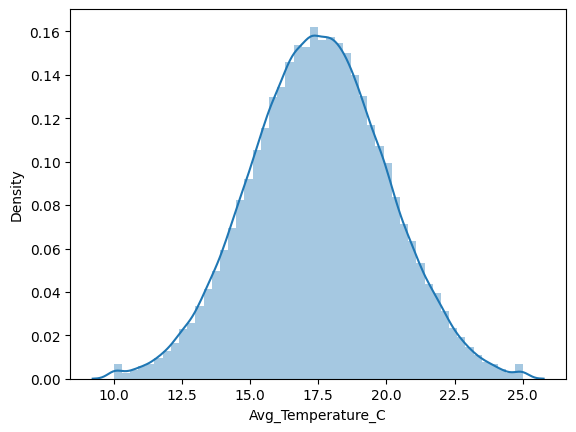

In [38]:
sns.distplot(df['Avg_Temperature_C'])

In [39]:
df['Has_AC'] = df['Has_AC'].map({'Yes': 1, 'No': 0})

In [40]:
df.sample(10)

,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
85442,2025-04-01,14.0,6,16.0,0,4.8
24144,2025-04-02,20.0,6,19.8,1,8.5
73570,2025-04-01,20.0,6,19.4,1,8.9
13659,2025-04-03,7.3,2,20.8,0,2.7
27441,2025-04-02,19.5,6,18.9,1,9.3
47053,2025-04-07,20.0,6,14.8,1,8.1
61781,2025-04-07,10.8,2,17.2,1,4.4
12962,2025-04-06,8.7,4,18.8,0,2.7
22453,2025-04-05,3.5,1,16.5,1,1.7
34714,2025-04-02,2.6,1,17.9,1,1.1


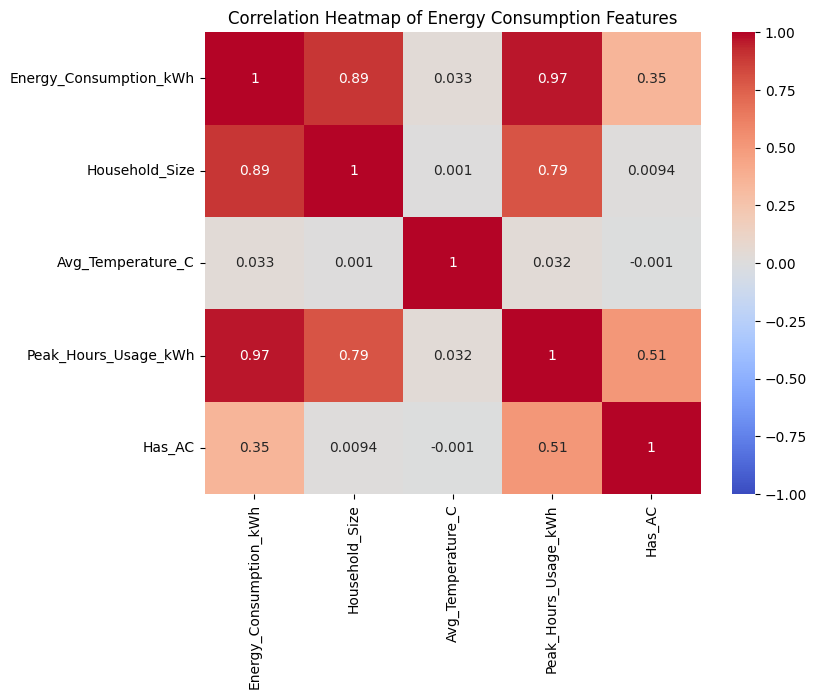

In [41]:
numerical_cols = ['Energy_Consumption_kWh', 'Household_Size', 'Avg_Temperature_C',
                  'Peak_Hours_Usage_kWh', 'Has_AC']
df_numerical = df[numerical_cols]

# Step 3: Compute correlation matrix
corr_matrix = df_numerical.corr()

# Step 4: Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Energy Consumption Features')
plt.show()

In [42]:
print(df['Avg_Temperature_C'].describe())

count    90000.000000
mean        17.505802
std          2.491621
min         10.000000
25%         15.800000
50%         17.500000
75%         19.200000
max         25.000000
Name: Avg_Temperature_C, dtype: float64


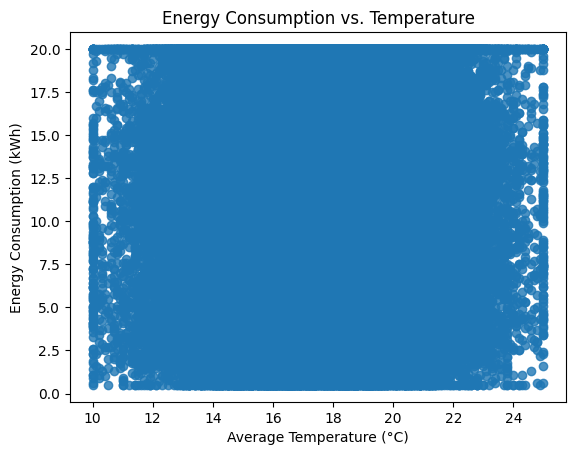

In [43]:
import matplotlib.pyplot as plt
plt.scatter(df['Avg_Temperature_C'], df['Energy_Consumption_kWh'], alpha=0.8)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Energy Consumption (kWh)')
plt.title('Energy Consumption vs. Temperature')
plt.show()

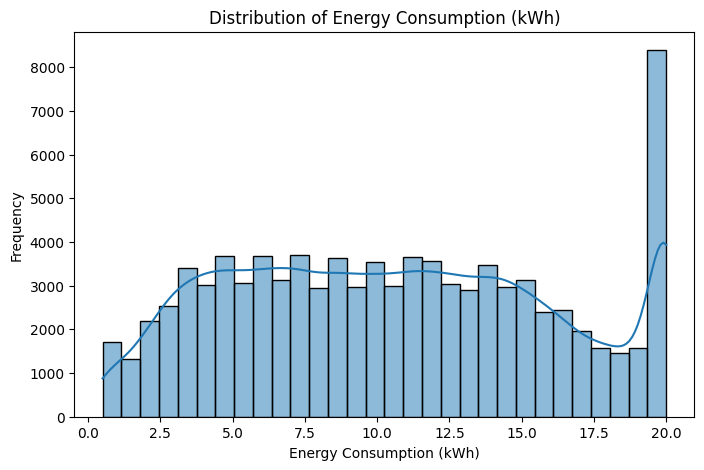

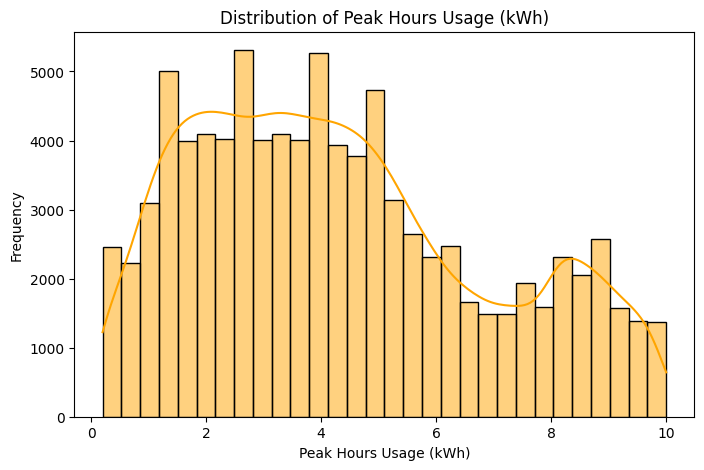

<ipython-input-44-29b9840e7a73>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Has_AC', data=df, palette='pastel')


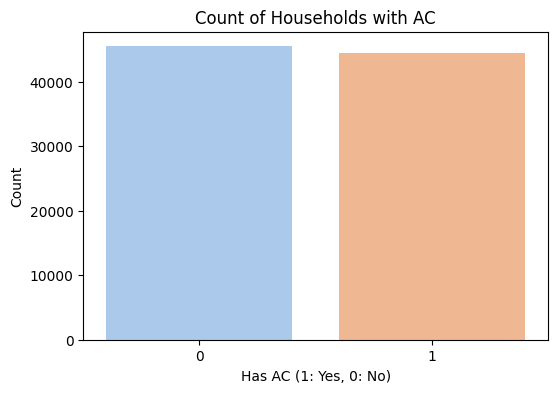

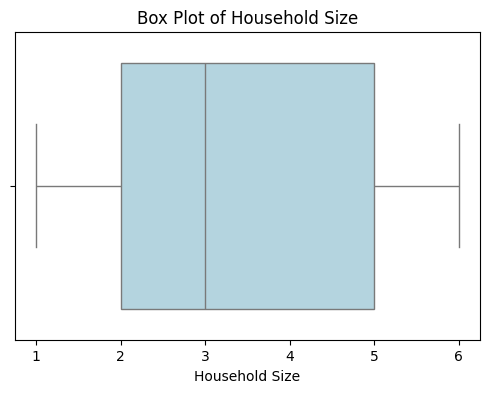

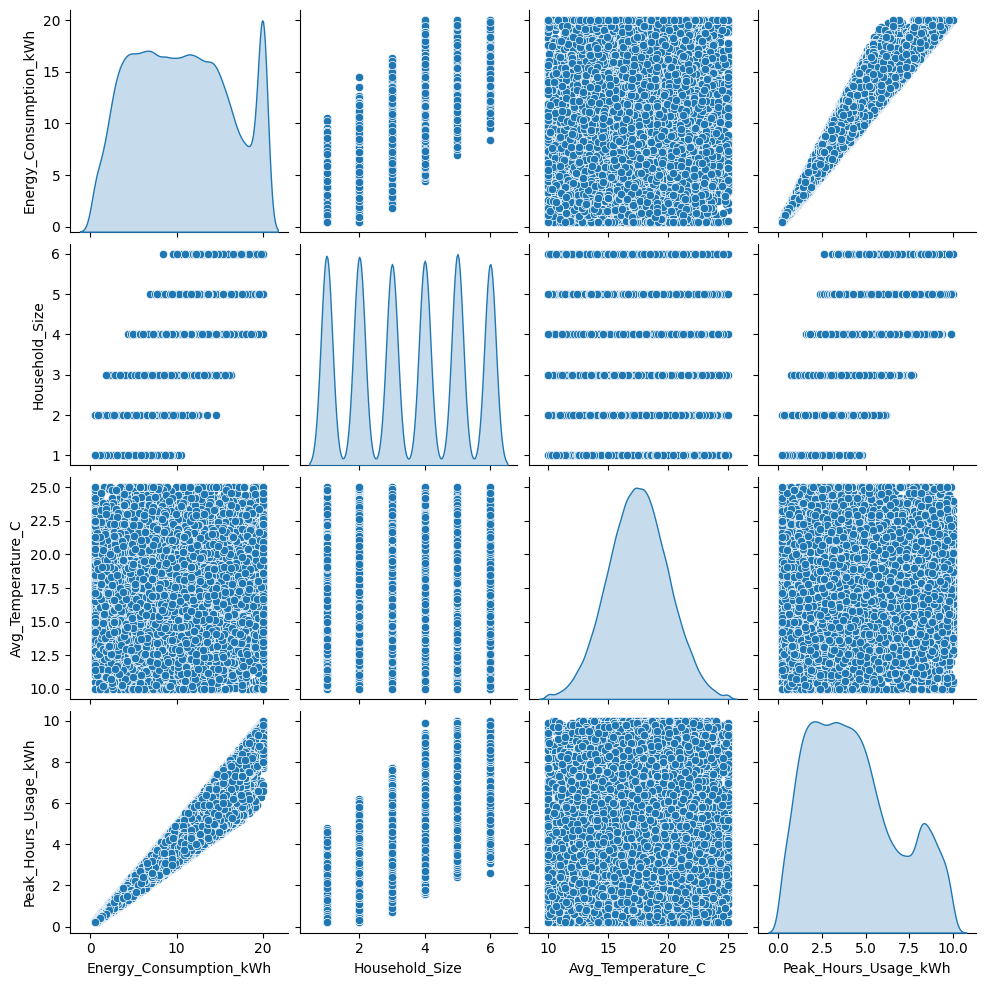

In [44]:
# Histogram for Energy Consumption
plt.figure(figsize=(8, 5))
sns.histplot(df['Energy_Consumption_kWh'], kde=True, bins=30)
plt.title('Distribution of Energy Consumption (kWh)')
plt.xlabel('Energy Consumption (kWh)')
plt.ylabel('Frequency')
plt.show()

# Histogram for Peak Hours Usage
plt.figure(figsize=(8, 5))
sns.histplot(df['Peak_Hours_Usage_kWh'], kde=True, bins=30, color='orange')
plt.title('Distribution of Peak Hours Usage (kWh)')
plt.xlabel('Peak Hours Usage (kWh)')
plt.ylabel('Frequency')
plt.show()

# Countplot for Has_AC (Pie chart alternative)
plt.figure(figsize=(6, 4))
sns.countplot(x='Has_AC', data=df, palette='pastel')
plt.title('Count of Households with AC')
plt.xlabel('Has AC (1: Yes, 0: No)')
plt.ylabel('Count')
plt.show()

# Box Plot for Household Size
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Household_Size'], color='lightblue')
plt.title('Box Plot of Household Size')
plt.xlabel('Household Size')
plt.show()

# Pair Plot for selected numeric variables to explore pairwise relationships
numeric_columns = ['Energy_Consumption_kWh', 'Household_Size', 'Avg_Temperature_C', 'Peak_Hours_Usage_kWh']
sns.pairplot(df[numeric_columns], diag_kind='kde')
plt.show()

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

In [55]:
df.columns

Index(['Date', 'Energy_Consumption_kWh', 'Household_Size', 'Avg_Temperature_C',
       'Has_AC', 'Peak_Hours_Usage_kWh'],
      dtype='object')

In [56]:
target = 'Peak_Hours_Usage_kWh'

In [57]:
features = ['Energy_Consumption_kWh', 'Household_Size', 'Avg_Temperature_C',
       'Has_AC']

In [58]:
X=df[features]
y=df[target]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
model = LinearRegression()

In [64]:
model.fit(X_train, y_train)

LinearRegression()

In [65]:
y_pred = model.predict(X_test)

In [67]:
y_pred.shape

(18000,)

In [68]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('RMSE:', rmse)

RMSE: 0.4172158007884368


In [69]:
r2 = r2_score(y_test, y_pred)

print('R2 Score:', r2)



R2 Score: 0.9727709375992288


In [70]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error:', mae)

Mean Absolute Error: 0.3382508609434782


In [71]:
# prompt: apply logistic regression

from sklearn.linear_model import LogisticRegression

# Assuming 'Has_AC' is the target variable for logistic regression
target = 'Has_AC'
features = ['Energy_Consumption_kWh', 'Household_Size', 'Avg_Temperature_C',
            'Peak_Hours_Usage_kWh']

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logreg_model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
logreg_model.fit(X_train, y_train)

y_pred_logreg = logreg_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_logreg)
print(f"Accuracy: {accuracy}")

print(classification_report(y_test, y_pred_logreg))

conf_matrix = confusion_matrix(y_test, y_pred_logreg)
print("Confusion Matrix:")
conf_matrix


Accuracy: 0.9907222222222222
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9087
           1       0.99      0.99      0.99      8913

    accuracy                           0.99     18000
   macro avg       0.99      0.99      0.99     18000
weighted avg       0.99      0.99      0.99     18000

Confusion Matrix:


array([[9031,   56],
       [ 111, 8802]])